In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
import flows.extension as extension
import flows.shear as shear
from utils.interpolate import interpolate_stress
from models import *
from models.FENE import *

In [5]:
ndim = 3  # Spatial dimensions

## Steady Extension

In [6]:
Wimax = 1e3  # Maximum Weissenberg number
models = [
    Oldroyd_B.Oldroyd_B,
    FENE_P.FENE_P,
    ePTT.ePTT,
    Giesekus.Giesekus
]
model_parameters = [
    {"β":0.0},
    {"β":0.0, "L":10},
    {"β":0.0, "ε":0.25},
    {"β":0.0, "α":0.2}
]

In [7]:
res_steady = []  # Result of every model requested
for idx, model in enumerate(models):
    Wi_uniaxi, τ_uniaxi = extension.steady(ndim, 0, Wimax, model, model_parameters[idx])
    Wi_planar, τ_planar = extension.steady(ndim, 1, Wimax, model, model_parameters[idx])

    Wi_shear, τ_shear = shear.steady(ndim, Wimax, model, model_parameters[idx])
    τ_ushear = interpolate_stress(Wi_uniaxi, Wi_shear, τ_shear)
    τ_pshear = interpolate_stress(Wi_planar, Wi_shear, τ_shear)

    res_steady.append((Wi_uniaxi, τ_uniaxi, τ_ushear, Wi_planar, τ_planar, τ_pshear))

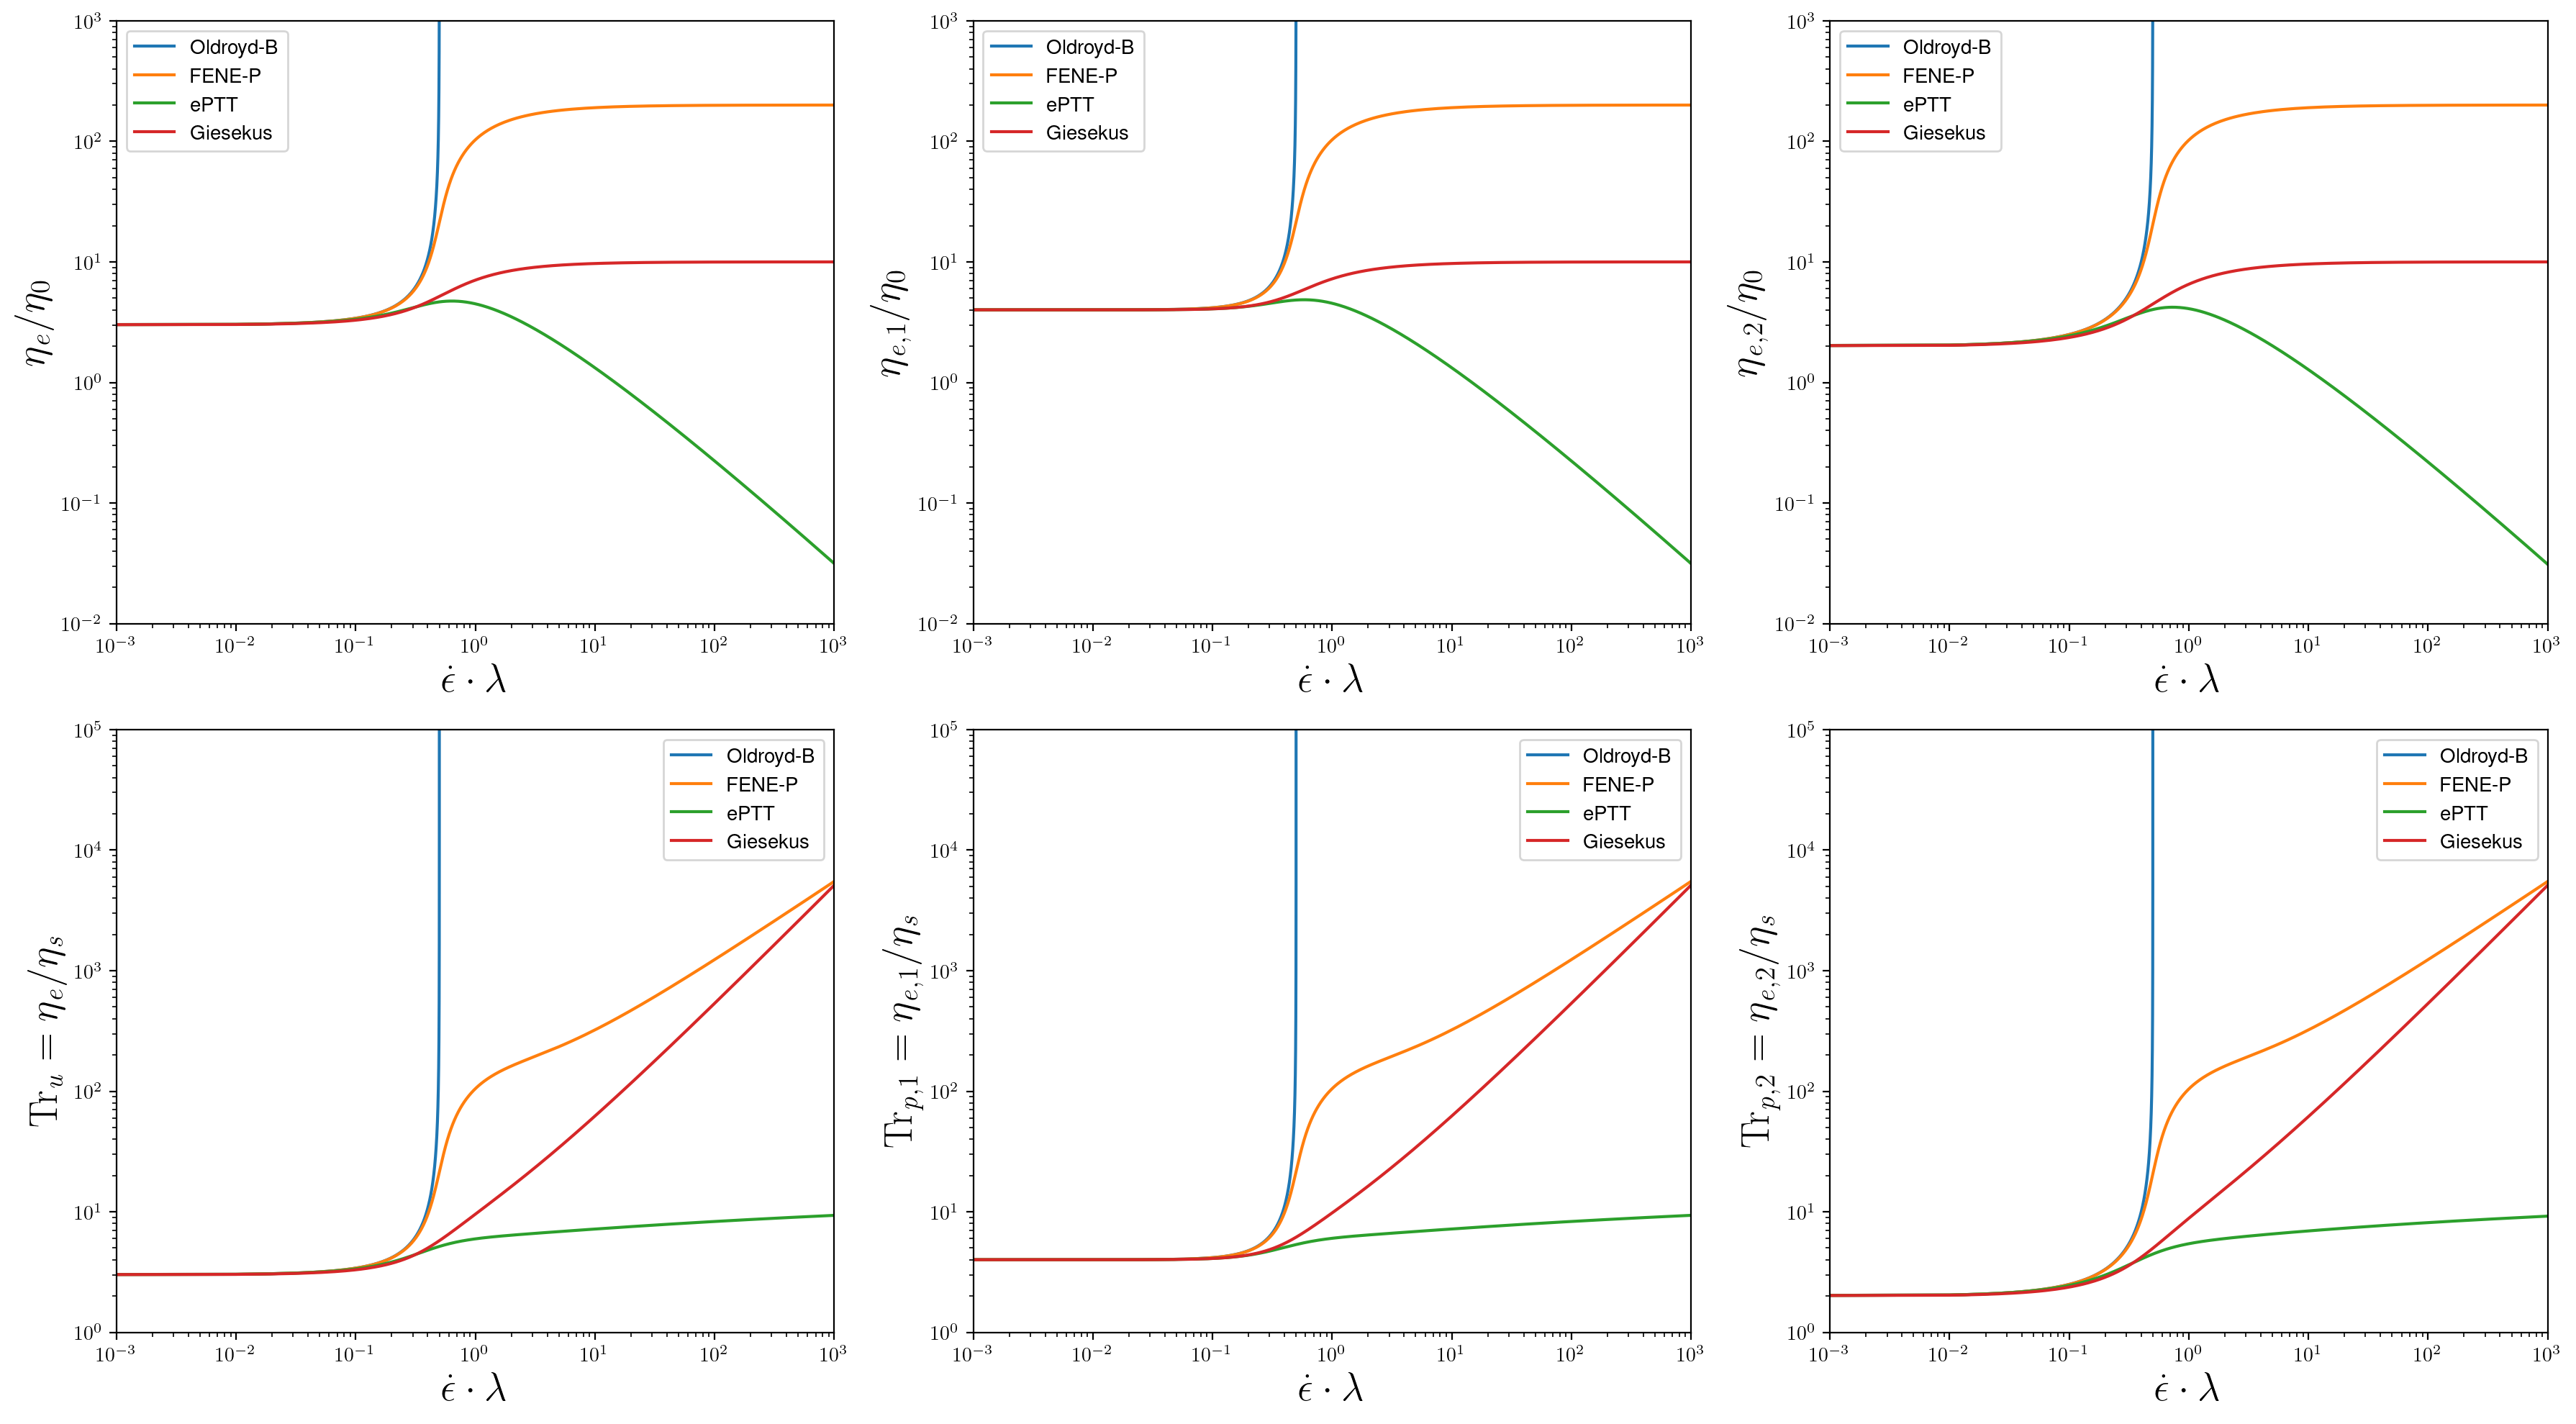

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

for idx, model in enumerate(models):
    Wi_uniaxi, τ_uniaxi, τ_ushear, Wi_planar, τ_planar, τ_pshear = res_steady[idx]
    axes[0,0].plot(Wi_uniaxi, (τ_uniaxi[:,2,2]-τ_uniaxi[:,0,0])/Wi_uniaxi, label=model.name)
    axes[0,1].plot(Wi_planar, (τ_planar[:,2,2]-τ_planar[:,0,0])/Wi_planar, label=model.name)
    axes[0,2].plot(Wi_planar, (τ_planar[:,2,2]-τ_planar[:,1,1])/Wi_planar, label=model.name)

    axes[1,0].plot(Wi_uniaxi, (τ_uniaxi[:,2,2]-τ_uniaxi[:,0,0])/τ_ushear[:,0,1], label=model.name)
    axes[1,1].plot(Wi_planar, (τ_planar[:,2,2]-τ_planar[:,0,0])/τ_pshear[:,0,1], label=model.name)
    axes[1,2].plot(Wi_planar, (τ_planar[:,2,2]-τ_planar[:,1,1])/τ_pshear[:,0,1], label=model.name)


axes[0,0].set_ylabel("$\\eta_\\mathit{e} / \\eta_0$", size=20)
axes[0,1].set_ylabel("$\\eta_{\\mathit{e},1} / \\eta_0$", size=20)
axes[0,2].set_ylabel("$\\eta_{\\mathit{e},2} / \\eta_0$", size=20)

axes[1,0].set_ylabel("$\\mathrm{Tr}_\\mathit{u} = \\eta_\\mathit{e} / \\eta_\\mathit{s}$", size=20)
axes[1,1].set_ylabel("$\\mathrm{Tr}_{\\mathit{p},1} = \\eta_{\\mathit{e},1} / \\eta_\\mathit{s}$", size=20)
axes[1,2].set_ylabel("$\\mathrm{Tr}_{\\mathit{p},2} = \\eta_{\\mathit{e},2} / \\eta_\\mathit{s}$", size=20)
for ax in axes.flatten():
    ax.set_xlabel("$\\dot{{\\epsilon}} \\cdot \\lambda$", size=20)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim([1e-3,Wimax])
    ax.legend()

axes[0,0].set_ylim([1e-2,1e3])
axes[0,1].set_ylim([1e-2,1e3])
axes[0,2].set_ylim([1e-2,1e3])

axes[1,0].set_ylim([1e0,1e5])
axes[1,1].set_ylim([1e0,1e5])
axes[1,2].set_ylim([1e0,1e5])

plt.tight_layout()
plt.show()

## Extension Step

In [9]:
from scipy.integrate import RK45, Radau, LSODA

In [10]:
Wi_step = 1.2
models = [
    Oldroyd_B.Oldroyd_B,
    Oldroyd_A.Oldroyd_A,
    FENE_CR.FENE_CR,
    FENE_P.FENE_P,
    Johnson_Segalman.Johnson_Segalman,
    Giesekus.Giesekus,
    FENE_P_Multimode.FENE_P_Multimode(6),
]
model_parameters = [
    {"β":0.0},
    {"β":0.0},
    {"β":0.0, "L":100},
    {"β":0.0, "L":100},
    {"β":0.0, "ε0":0.2},
    {"β":0.0, "α":0.9},
    {"β":[0.1, 0.2, 0.3, 0.2, 0.1, 0.1], "L": [100, 80, 60, 40, 20, 10], "λfrac": [1.0, 0.8, 0.6, 0.4, 0.2, 0.1]},
]

In [11]:
res_step = []  # Result of every model requested
for idx, model in enumerate(models):
    t_uniaxi, τ_uniaxi = extension.step(ndim, 0, Wi_step, model, model_parameters[idx], ODESolver=LSODA, tmax=1e2, tchange=0.2)
    t_planar, τ_planar = extension.step(ndim, 1, Wi_step, model, model_parameters[idx], ODESolver=LSODA, tmax=1e2, tchange=0.2)
    res_step.append((t_uniaxi, τ_uniaxi, t_planar, τ_planar))

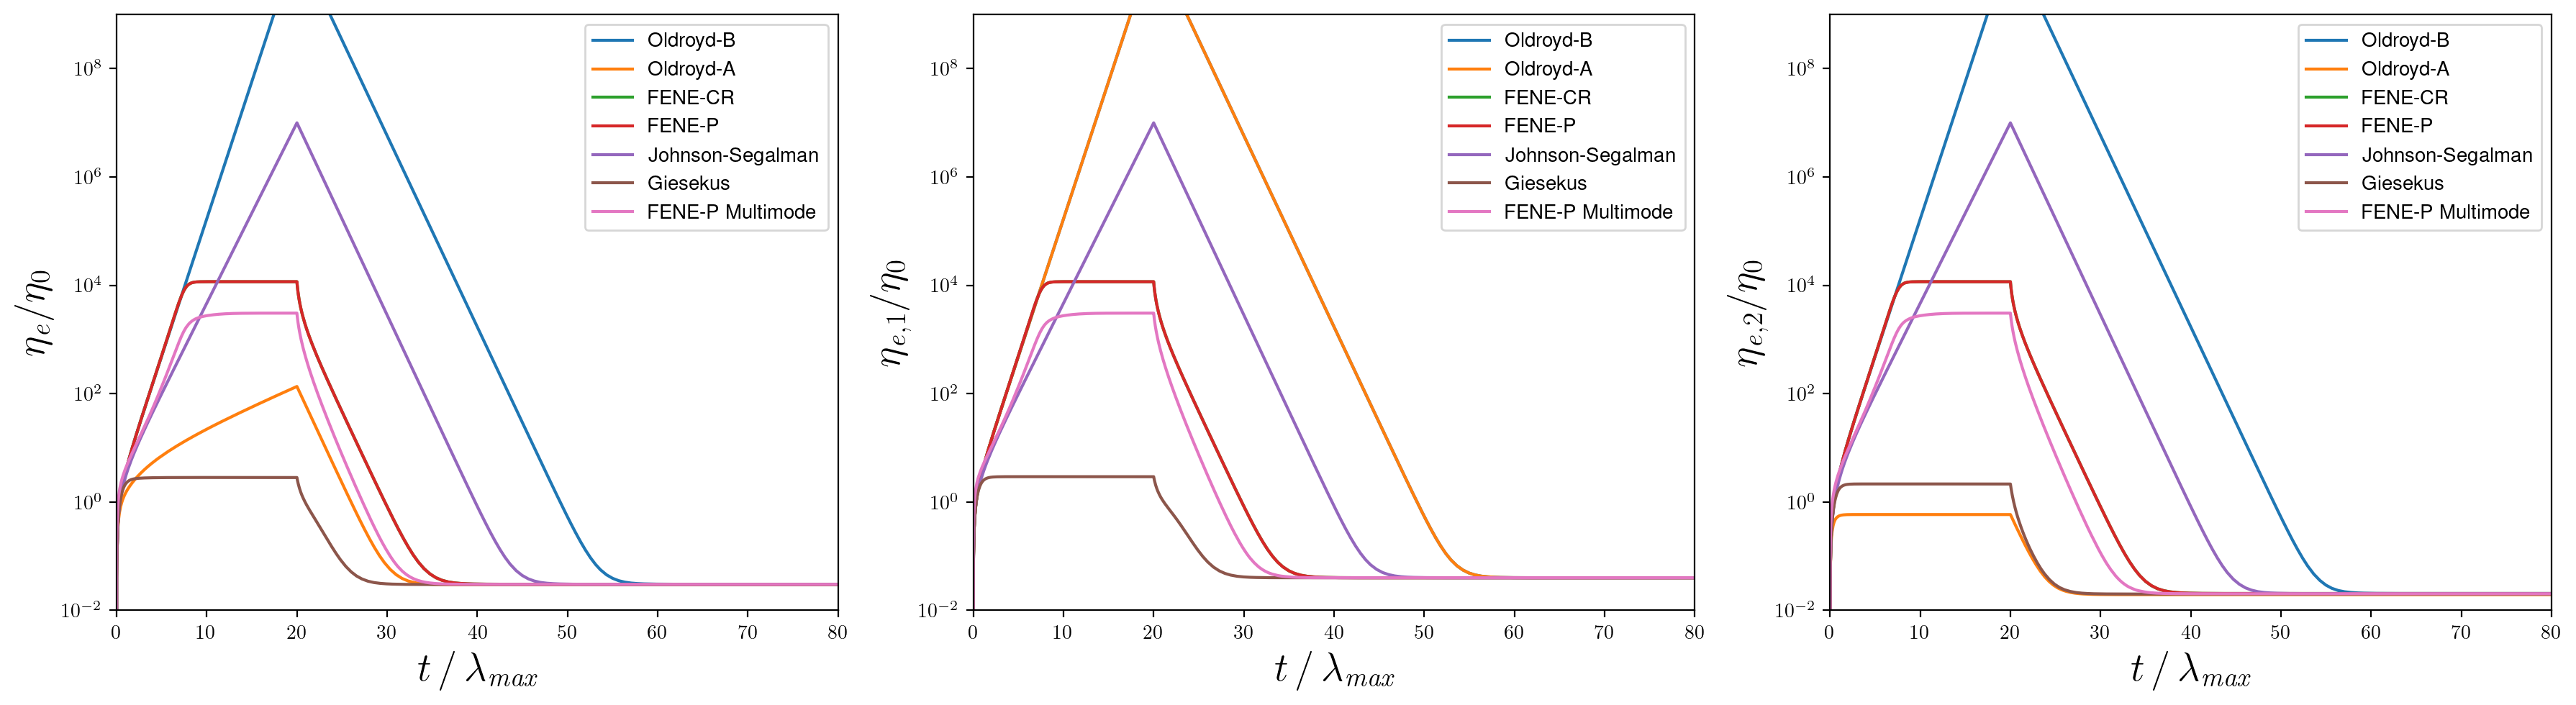

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for idx, model in enumerate(models):
    t_uniaxi, τ_uniaxi, t_planar, τ_planar = res_step[idx]
    axes[0].plot(t_uniaxi, (τ_uniaxi[:,2,2]-τ_uniaxi[:,0,0])/Wi_step, label=model.name)
    axes[1].plot(t_planar, (τ_planar[:,2,2]-τ_planar[:,0,0])/Wi_step, label=model.name)
    axes[2].plot(t_planar, (τ_planar[:,2,2]-τ_planar[:,1,1])/Wi_step, label=model.name)

axes[0].set_ylabel("$\\eta_\\mathit{e} / \\eta_0$", size=20)
axes[1].set_ylabel("$\\eta_{\\mathit{e},1} / \\eta_0$", size=20)
axes[2].set_ylabel("$\\eta_{\\mathit{e},2} / \\eta_0$", size=20)
for ax in axes:
    ax.set_xlabel("$t \\,/\\, \\lambda_\\mathit{max}$", size=20)
    ax.set_yscale("log")
    ax.set_xlim([0,80])
    ax.legend()
axes[0].set_ylim([1e-2,1e9])
axes[1].set_ylim([1e-2,1e9])
axes[2].set_ylim([1e-2,1e9])
plt.tight_layout()
plt.show()